In [1]:
#1) Import Pandas, Matplotlib, Numpy, Statsmodels, Seaborn, and Scipy.  Do not use any other libraries.  No output is necessary here.

import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import reset_ramsey
from statsmodels.graphics.regressionplots import plot_partregress_grid

import scipy.stats as stats
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

#2) Import your CSV file into Python as a Pandas dataframe.  Print the top five rows and data types for each variable.

housing_dataset= pd.read_csv('C:/Users/rupas/Desktop/Applied Business Statistics/4266261_Rupa_Shrestha_Assignment-2/dataset/housing.csv')
print(housing_dataset.head())



     price  area  bedrooms  bathrooms  stories fireplace basement central_air  \
0  1330000  7420         4          2        3        no       no         yes   
1  1225000  8960         4          4        4        no       no         yes   
2  1225000  9960         3          2        2        no      yes          no   
3  1221500  7500         4          2        2        no      yes         yes   
4  1141000  7420         4          1        2       yes      yes         yes   

   covered_parking_spaces furnishingstatus  
0                       2        furnished  
1                       3        furnished  
2                       2   semi-furnished  
3                       3        furnished  
4                       2        furnished  


In [2]:
#3) Use Pandas to calculate summary statistics
housing_dataset.describe()

,price,area,bedrooms,bathrooms,stories,covered_parking_spaces
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+05,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+05,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+05,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+05,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+05,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+05,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+06,16200.000000,6.000000,4.000000,4.000000,3.000000


C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


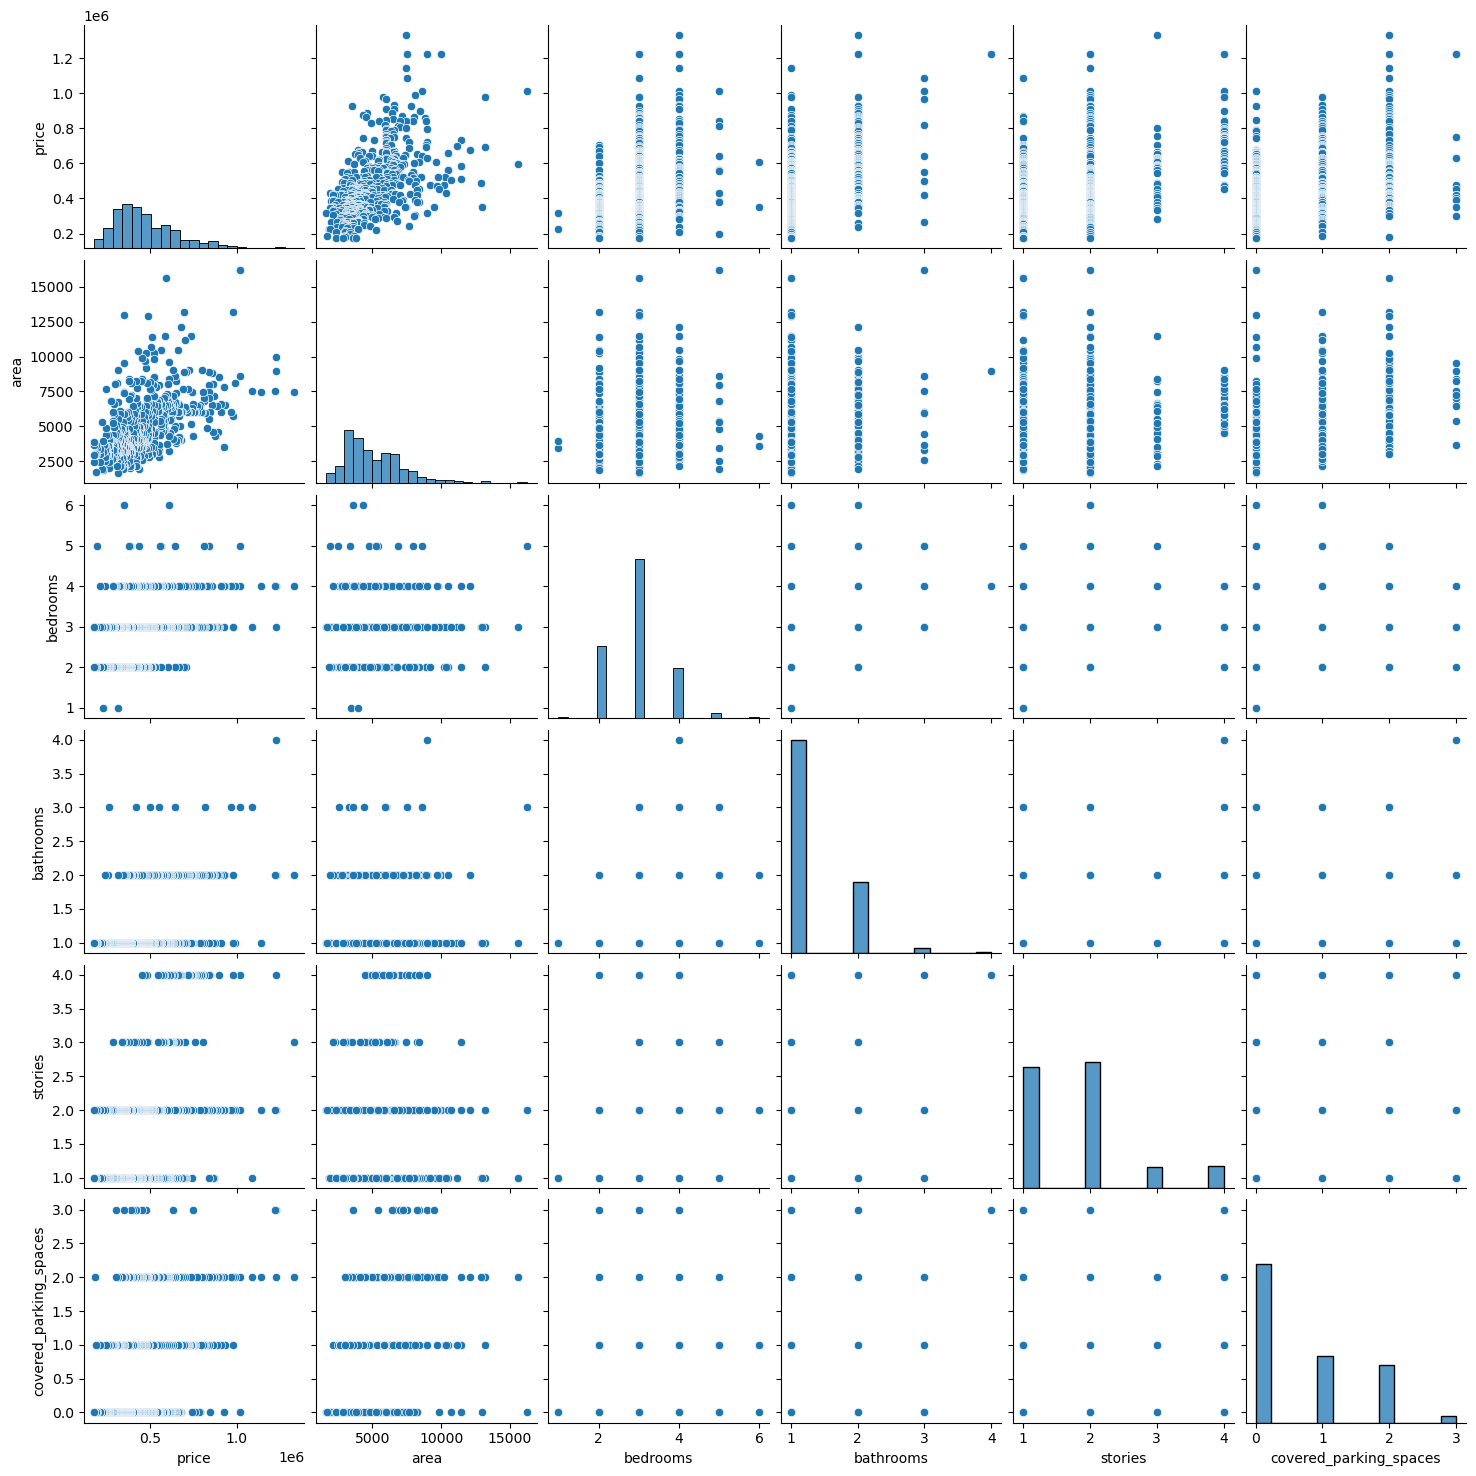

In [3]:
# 4) Use Seaborn’s pairplot function to produce the big graphic plotting each variable against each other variable. 

sns.pairplot(housing_dataset)
plt.show()

C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\rupas\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\r

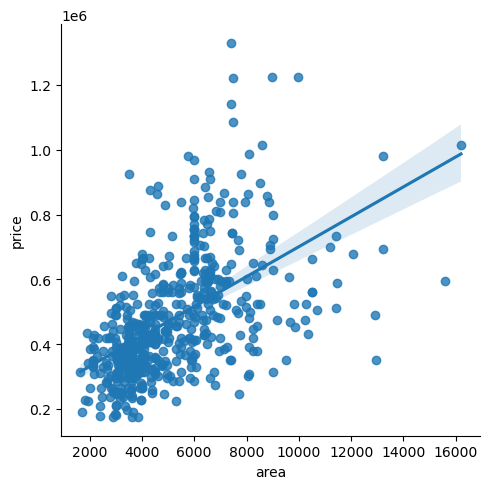

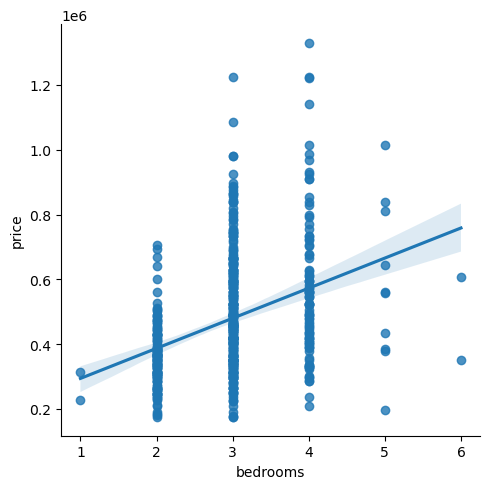

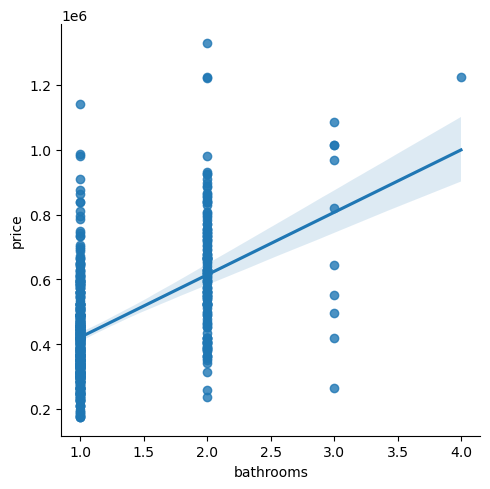

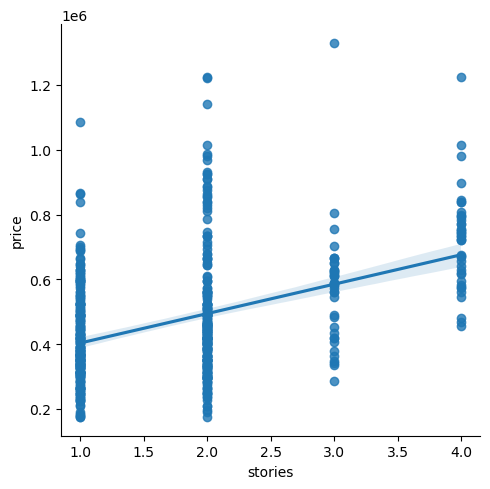

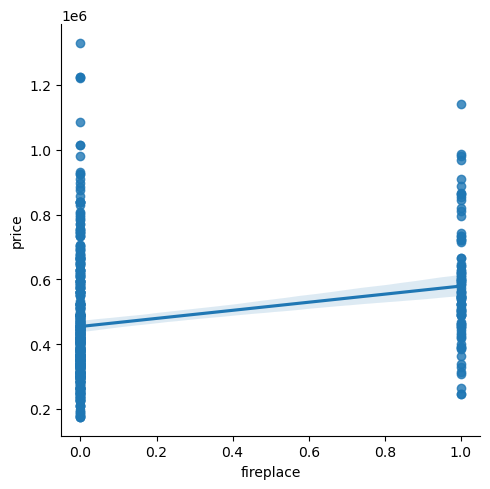

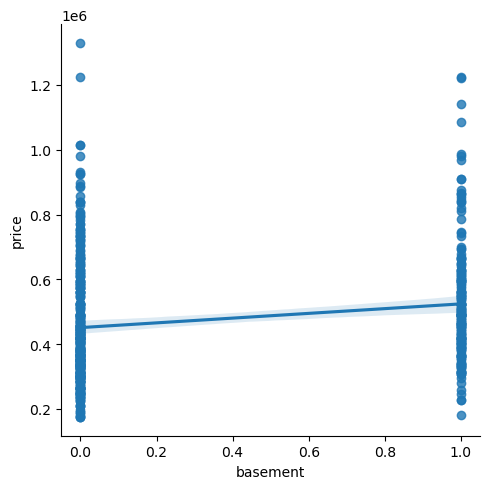

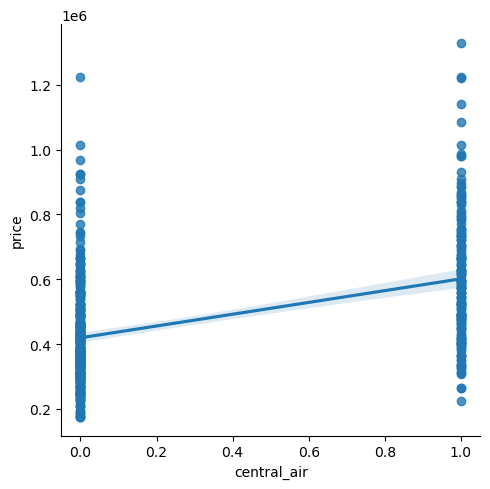

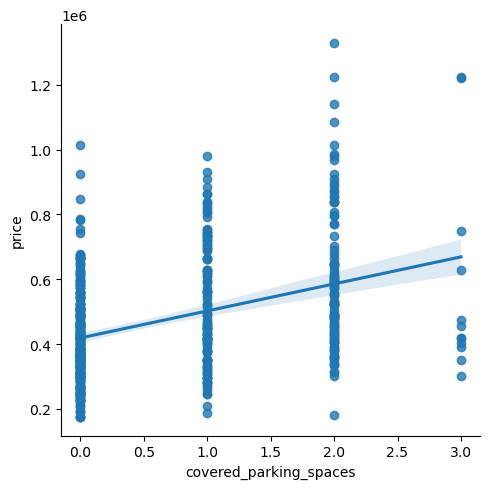

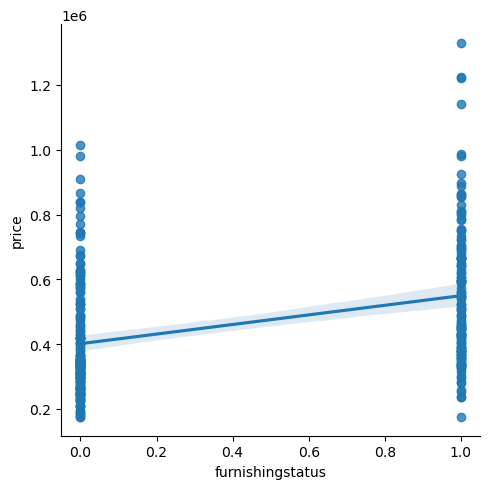

In [4]:

# 5)Create a list of your independent variables and use a loop to create a plot of each one against your dependent variable.  

# Converting categorical variables to numeric
housing_dataset['fireplace'] = housing_dataset['fireplace'].map({'yes': 1, 'no': 0})
housing_dataset['basement'] = housing_dataset['basement'].map({'yes': 1, 'no': 0})
housing_dataset['central_air'] = housing_dataset['central_air'].map({'yes': 1, 'no': 0})
housing_dataset['furnishingstatus'] = housing_dataset['furnishingstatus'].map({'furnished': 1, 'unfurnished': 0})

y = housing_dataset['price'] #dependent variable
xvars = ['area', 'bedrooms', 'bathrooms', 'stories', 'fireplace', 'basement', 
         'central_air', 'covered_parking_spaces', 'furnishingstatus']
X = housing_dataset[xvars] #independent variables

#Plotting each independent variable against the dependent variable
for i in xvars:
    sns.lmplot(x=i,y='price',fit_reg=True,data=housing_dataset)


In [5]:
# 6) Create three different linear regression models using different subsets of independent variables.  Print the regression results for each.

# Check for NaN 
print(X.isna().sum())  # Counts missing values (NaNs) in each column
print((X == float('inf')).sum())

# X['furnishingstatus'] = X['furnishingstatus'].fillna(method='ffill')
print(X.isna().sum())

#Add a constant to the independent variables data frame so that the regression includes an intercept term
X = sm.add_constant(X)
X.head()

y = housing_dataset['price'] #dependent variable
xvars = ['area', 'bedrooms', 'bathrooms', 'stories', 'fireplace', 'basement', 
         'central_air', 'covered_parking_spaces']
X = housing_dataset[xvars]

model1 = sm.OLS(y,X)
result1 = model1.fit()
summary1 = result1.summary()
print(summary1)


area                        0
bedrooms                    0
bathrooms                   0
stories                     0
fireplace                   0
basement                    0
central_air                 0
covered_parking_spaces      0
furnishingstatus          227
dtype: int64
area                      0
bedrooms                  0
bathrooms                 0
stories                   0
fireplace                 0
basement                  0
central_air               0
covered_parking_spaces    0
furnishingstatus          0
dtype: int64
area                        0
bedrooms                    0
bathrooms                   0
stories                     0
fireplace                   0
basement                    0
central_air                 0
covered_parking_spaces      0
furnishingstatus          227
dtype: int64
                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                  

In [6]:
y = housing_dataset['price'] #dependent variable
xvars = ['stories', 'fireplace', 'basement']
X = housing_dataset[xvars]

model2 = sm.OLS(y,X)
result2 = model2.fit()
summary2 = result2.summary()
print(summary2)

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.863
Model:                            OLS   Adj. R-squared (uncentered):              0.863
Method:                 Least Squares   F-statistic:                              1141.
Date:                Mon, 09 Dec 2024   Prob (F-statistic):                   9.87e-234
Time:                        21:53:54   Log-Likelihood:                         -7395.6
No. Observations:                 545   AIC:                                  1.480e+04
Df Residuals:                     542   BIC:                                  1.481e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [7]:
y = housing_dataset['price'] #dependent variable
xvars = ['central_air', 'covered_parking_spaces','basement','fireplace']
X = housing_dataset[xvars]

model3 = sm.OLS(y,X)
result3 = model3.fit()
summary3 = result3.summary()
print(summary3)

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.715
Model:                            OLS   Adj. R-squared (uncentered):              0.713
Method:                 Least Squares   F-statistic:                              339.8
Date:                Mon, 09 Dec 2024   Prob (F-statistic):                   5.11e-146
Time:                        21:54:00   Log-Likelihood:                         -7595.6
No. Observations:                 545   AIC:                                  1.520e+04
Df Residuals:                     541   BIC:                                  1.522e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [8]:
#HERE
# 7) Compare models using R^2, AIC, etc.
print("Model Comparison:")
print(f'Model 1: R^2={result1.rsquared}, AIC={result1.aic}')
print(f'Model 2: R^2={result2.rsquared}, AIC={result2.aic}')
print(f'Model 3: R^2={result3.rsquared}, AIC={result3.aic}')



Model Comparison:
Model 1: R^2=0.9514799271252592, AIC=14242.809460174461
Model 2: R^2=0.8633425995659249, AIC=14797.15667732076
Model 3: R^2=0.7152822734894773, AIC=15199.198225401715


In [9]:
# 8) Variance Inflation Factor (VIF)

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF) for Multicollinearity:")
print(vif_data)

Variance Inflation Factor (VIF) for Multicollinearity:
                 Variable       VIF
0             central_air  1.362917
1  covered_parking_spaces  1.376293
2                basement  1.543013
3               fireplace  1.427098


In [10]:
# 9) Predicted values and residuals
# best_model = model1  # Example selection

# y_hat = best_model.predict(X1)
# e = y1 - y_hat

# sns.scatterplot(x=y_hat, y=e)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.title('Residuals vs Predicted Values')
# plt.xlabel('Predicted Values (y_hat)')
# plt.ylabel('Residuals (e)')
# plt.show()

predictions = pd.DataFrame({'bedrooms': [1, 1, 3, 4, 5],
                            'bathrooms': [1, 1, 1, 2, 1],
                            'area':[2000,2000,1500,2000,3500],
                            'basement_yes':[1,0,1,0,1]})

predictions['estimated price'] = result3.predict(predictions)
print(predictions)

#Residuals
yhat1 = result1.fittedvalues
e1 = result1.resid
print("residuals",e1)
# predictions['estimated price'] = result3.predict(housing_dataset)

   bedrooms  bathrooms  area  basement_yes  estimated price
0         1          1  2000             1     4.575038e+08
1         1          1  2000             0     4.573756e+08
2         3          1  1500             1     3.439163e+08
3         4          2  2000             0     4.585072e+08
4         5          1  3500             1     8.014230e+08
residuals 0      566745.870307
1      132260.932860
2      481102.572957
3      420494.171413
4      439105.330667
           ...      
540   -198112.340603
541    -75172.791531
542   -102001.535069
543    -91723.452849
544   -170531.431606
Length: 545, dtype: float64


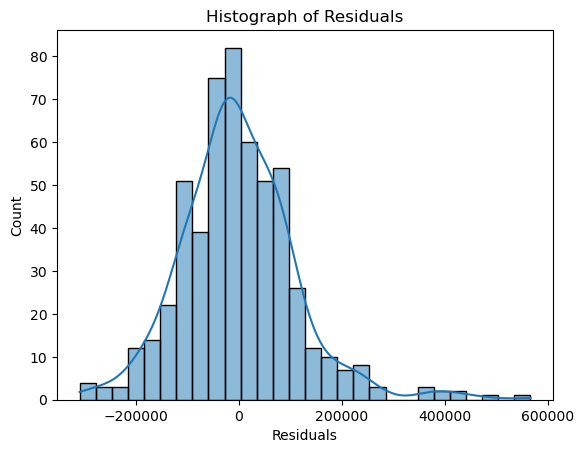

In [15]:
# 10) Histogram of residuals
sns.histplot(e1, kde=True)
plt.title('Histograph of Residuals')
plt.xlabel('Residuals')
plt.show()

# stat, p = normaltest(e1)
# print(f'Normality test p-value: {p}')
# if p > 0.05:
#     print("Residuals appear to be normally distributed.")
# else:
#     print("Residuals do not appear to be normally distributed.")

In [22]:
# 11) Test for heteroskedasticity
# _, pval, _, _ = het_breuschpagan(e, X1)
# print(f'Breusch-Pagan test p-value: {pval}')
# if pval > 0.05:
#     print("No heteroskedasticity detected.")
# else:
#     print("Heteroskedasticity detected.")

#Statistical tests for heteroskedasticity - Breusch Pagan and White
#HO: homoskedasticity, HA: heteroskedasticity
white_test = het_white(e1, X)
bp_test = het_breuschpagan(e1, X)
print("White's Test P-Value")
#print("LM Statistic:", white_test[0])
print("LM P-value:", white_test[1])
#print("F-Statistic:", white_test[2])
#print("F P-value:", white_test[3])
print("Breusch Pagan Test P-Value:")
print(bp_test[3])

#Interpretation:
#If the p-value of White's test is above the significance level (e.g., 0.05), we fail to reject the null hypothesis of homoskedasticity.
#If the p-value of Breusch-Pagan test is above the significance level (e.g., 0.05), we fail to reject the null hypothesis of homoskedasticity.

ValueError: White's heteroskedasticity test requires exog to have at least two columns where one is a constant.

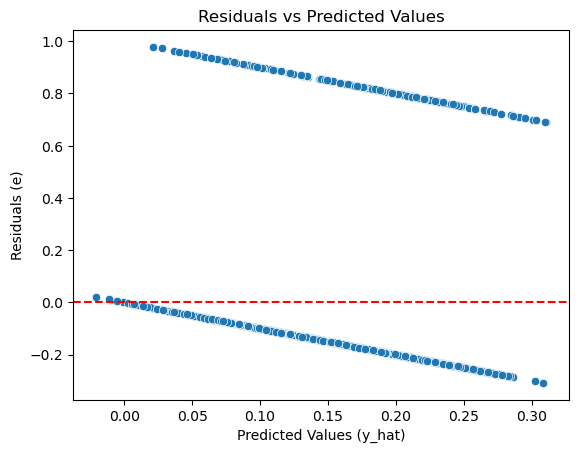

In [14]:
# 12) Standardized residuals
std_residuals = e / np.std(e)
outliers = np.abs(std_residuals) > 3
print(f'Number of outliers: {np.sum(outliers)}')

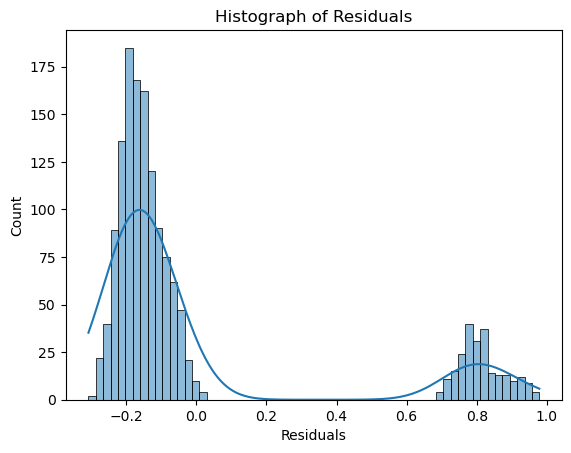

NameError: name 'normaltest' is not defined

In [16]:
# 13) Scatterplot of Y vs Y-Hat
sns.scatterplot(x=y_hat, y=y1)
sns.lineplot(x=y_hat, y=y_hat, color='red')
plt.title('Y vs Y-Hat with Trendline')
plt.xlabel('Predicted Y (Y-Hat)')
plt.ylabel('Actual Y')
plt.show()


In [17]:
# 14) Residuals vs X-variables
for var in independent_vars:
    sns.scatterplot(x=dataset[var], y=e)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residuals vs {var}')
    plt.show()

Breusch-Pagan test p-value: 9.774248112145456e-08
Heteroskedasticity detected.


In [18]:
# 15) Predictions for hypothetical observations
new_data = pd.DataFrame({
    'Age': [30, 40, 50, 60, 35],
    'DailyRate': [500, 700, 800, 900, 1000],
    'DistanceFromHome': [5, 10, 3, 8, 2],
    'MonthlyIncome': [4000, 6000, 7000, 9000, 4500]
})

# Adjust columns for the selected model (['Age', 'DailyRate'])
new_data = new_data[['Age', 'DailyRate']]
new_data = sm.add_constant(new_data)

predicted_y = best_model.predict(new_data)
print(predicted_y)

Number of outliers: 0


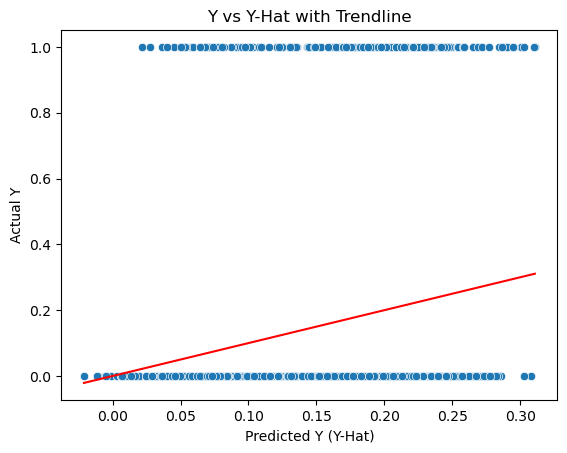

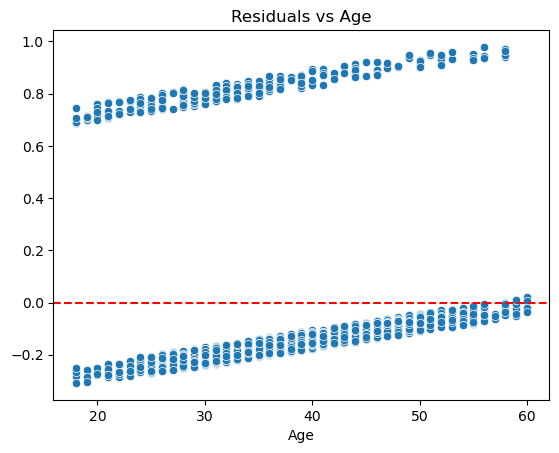

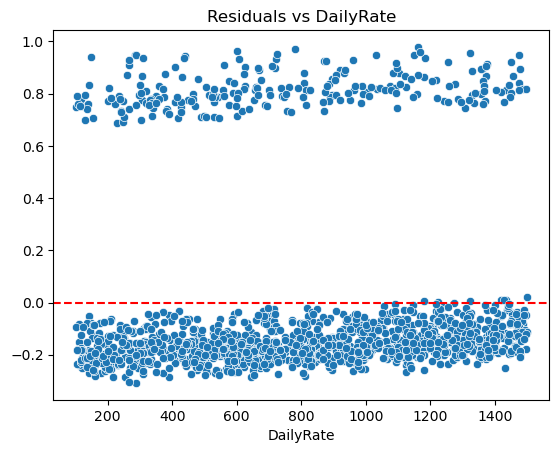

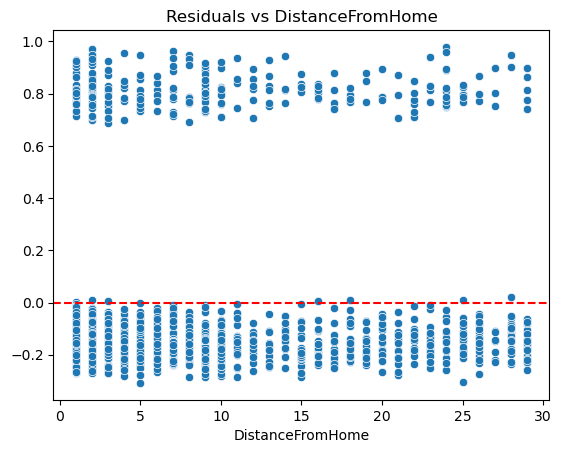

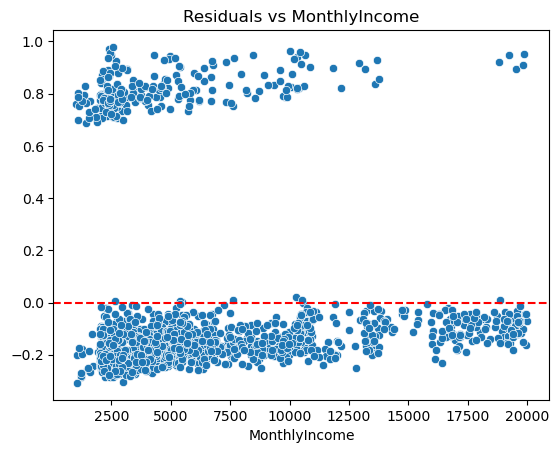

0    0.220605
1    0.146711
2    0.077828
3    0.008945
4    0.163616
dtype: float64
